<h1 style="color:orange">Feature Engineering</h1>

<a href="https://app.notion.com/p/builderslab/Perform-Data-Cleaning-and-Preprocessing-371663a5d5d180648531ce25fee5909b">
  <img src="https://cdn.simpleicons.org/notion/000000" width="16" style="vertical-align:middle; margin-right:4px"/> Notion Task
</a>
&nbsp;|&nbsp;
<a href="https://github.com/BuildersLab/Credit-Risk-Default">
  <img src="https://cdn.simpleicons.org/github/181717" width="16" style="vertical-align:middle; margin-right:4px"/> GitHub Repo
</a>

## Table of Contents

1. [Import Libraries and Load Dataset](#import-libraries-and-load-dataset)
2. [Feature Engineering Plan](#feature-engineering-plan)
3. [Feature Engineering](#feature-engineering)
   - [1. Temporal Features](#1-temporal-features)
   - [2. Domain-Specific Features](#2-domain-specific-features)
   - [3. Feature Validation](#3-feature-validation)
   - [4. Correlation Matrix](#4-correlation-matrix)
   - [5. Confirmed Features](#5-confirmed-features)
4. [Missingness Check](#missingness-check)
5. [Data Dictionary & Statistics Export](#data-dictionary-export)
6. [Save the Dataset](#save-to-huggingface)

### Documentation

**Dataset Source:** [BuildersLab/loan-application-dataset](https://huggingface.co/datasets/BuildersLab/loan-application-dataset) on Hugging Face.

---

**Feature Engineering Steps:**

| Step | Description |
|---|---|
| 1. Temporal Features | Derive `credit_history_months` from the raw date columns, then drop the raw dates |
| 2. Domain-Specific Features | FICO midpoint, affordability ratios (capped the 99.9th percentile), ordinal encodings, and dropping high-cardinality/redundant columns |
| 3. Feature Validation | Check each new feature's correlation with the target for signal and leakage |
| 4. Correlation Matrix | Full feature x feature and feature x target correlation, exported to CSV |
| 5. Confirmed Features | Final feature list, moved into `src/features.py` |
| 6. Data Dictionary & Statistics Export | 4-sheet Excel workbook (dictionary, dictionary + stats, correlation matrix, correlation vs target), saved locally and to Hugging Face |

<h2 style="color:orange"><a id="import-libraries-and-load-dataset"></a>I. Import Libraries and Load Dataset</h2>

In [1]:
# Import libraries
import os
import time
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from itables import init_notebook_mode, show
from IPython.display import Javascript, display

In [2]:
# Define directory path
BASE_DIR = os.path.dirname(os.path.abspath(os.getcwd()))

# Define path to output folder
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

# Print the base directory
print(f"Base directory: {BASE_DIR}")

Base directory: C:\Users\Nafis\BuildersLab_projects\Projects_Cleanup\Credit-Risk-Default


In [3]:
# Display all columns in the output 
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

"""# Display all interactive tables in the notebook
init_notebook_mode(all_interactive=True)"""

# Set dark mode for the notebook
display(Javascript("document.documentElement.classList.add('dark');"))

# Output formatting
import itables

itables.options.css = """
.dt-container th {
    background-color: #F05A24;
    color: white;
}

.dt-container td, .dt-container th {
    text-align: left;
    vertical-align: middle;
}

.dt-paging .current, .dt-paging .active a {
    background-color: #F05A24 !important;
    border-color: #F05A24 !important;
    color: white !important;
}

.dt-search input:focus, .dt-length select:focus {
    border-color: #F05A24;
}

table.dataTable thead .dt-column-order:after {
    color: #F05A24;
}
"""

from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)

<IPython.core.display.Javascript object>

In [4]:
# Import the dataset from Hugging Face
from datasets import load_dataset

# Define the repository ID and target configuration
REPO_ID = "BuildersLab/loan-application-dataset"
TARGET = "default"

# Load the dataset from Hugging Face
dataset = load_dataset(REPO_ID)  # picks up the "default" config: train/validation/test splits
print(dataset)

# Convert the dataset to pandas DataFrames
train = dataset["train"].to_pandas()
val = dataset["validation"].to_pandas()
test = dataset["test"].to_pandas()

# Print the shape of each split
for name, split in [("train", train), ("val", val), ("test", test)]:
    print(f"{name}: {split.shape}")

README.md: 0.00B [00:00, ?B/s]

C:\Users\Nafis\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Nafis\.cache\huggingface\hub\datasets--BuildersLab--loan-application-dataset. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


train.parquet:   0%|          | 0.00/84.2M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'application_type', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'chargeoff_within_12_mths', 'delinq_amnt', 'mort_acc', 'pub_rec_bankruptcies', 'tax_liens', 'mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 'mths_since_recent_inq', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mths_since_recent_bc', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_re

train: (941744, 111)
val: (201803, 111)
test: (201802, 111)


<h2 style="color:orange"><a id="feature-engineering-plan"></a>II. Feature Engineering Plan</h2>

| Section | New feature | Source column(s) | Description / rationale |
|---|---|---|---|
| Temporal | `credit_history_months` | `earliest_cr_line`, `issue_d` | Months between the borrower's earliest reported credit line and this loan's issue date, i.e. how long they've had credit history at the time they applied. Longer history generally means lower risk. |
| Temporal | *(drop)* `earliest_cr_line`, `issue_d` | - | Raw dates aren't usable directly by the model. `issue_d` also risks the model learning economic-cycle effects (e.g. 2008 crisis) rather than borrower behaviour. Both dropped after `credit_history_months` is derived. |
| Domain-specific | `fico_score` | `fico_range_low`, `fico_range_high` | Midpoint of LendingClub's reported FICO range: `(fico_range_low + fico_range_high) / 2`. A single representative score instead of two near-duplicate bounds. |
| Domain-specific | `loan_to_income` | `loan_amnt`, `annual_inc` | `loan_amnt / annual_inc`. How large the request is relative to what the borrower earns. |
| Domain-specific | `installment_to_income` | `installment`, `annual_inc` | `(installment * 12) / annual_inc`. Share of annual income committed to this loan's payments, a direct affordability signal. |
| Categorical | `emp_length_years` | `emp_length` | Convert text ("10+ years", "< 1 year") to a plain ordinal number (0-10). |
| Categorical | `term_months` | `term` | Convert text ("36 months", "60 months") to plain numeric 36/60. |
| Geographic | *(drop)* `zip_code` | - | ~900 distinct 3-digit prefixes, most with negligible individual signal. `addr_state` already captures state-level risk/regulatory/economic differences at far lower cardinality, without the dimensionality blowup. |
| Redundancy check | *(drop 1-2 of)* `loan_amnt`, `funded_amnt`, `funded_amnt_inv` | all three | Check pairwise correlation first. For resolved loans these are expected to be near-identical (`funded_amnt` is what LC actually committed, `funded_amnt_inv` is the investor-funded portion of that), so likely redundant. |

<h2 style="color:orange"><a id="feature-engineering"></a>III. Feature Engineering</h2>

- [1. Temporal Features](#1-temporal-features)
- [2. Domain-Specific Features](#2-domain-specific-features)
- [3. Feature Validation](#3-feature-validation)
- [4. Correlation Matrix](#4-correlation-matrix)
- [5. Confirmed Features](#5-confirmed-features)

<h3 style="color:orange"><a id="1-temporal-features"></a>1. Temporal Features</h3>

`credit_history_months`: months between the borrower's earliest reported credit line and this loan's issue date. Both raw date columns are dropped afterward.

In [5]:
# Define the splits dictionary
SPLITS = {"train": train, "val": val, "test": test}

# Calculate credit history months for each split
for name, split in SPLITS.items():
    # Convert issue_d and earliest_cr_line to datetime
    issue = pd.to_datetime(split["issue_d"], format="%b-%Y")
    earliest = pd.to_datetime(split["earliest_cr_line"], format="%b-%Y")

    # Calculate credit history in months
    split["credit_history_months"] = (issue.dt.year - earliest.dt.year) * 12 + (
        issue.dt.month - earliest.dt.month
    )

    # Drop the original columns
    split.drop(columns=["issue_d", "earliest_cr_line"], inplace=True)

# Display the descriptive statistics for credit history months in the training set
train["credit_history_months"].describe()

count    941744.000000
mean        195.114593
std          90.032498
min          36.000000
25%         135.000000
50%         177.000000
75%         240.000000
max         852.000000
Name: credit_history_months, dtype: float64

<h3 style="color:orange"><a id="2-domain-specific-features"></a>2. Domain-Specific Features</h3>

- `fico_score`: midpoint of `fico_range_low`/`fico_range_high`, both dropped after.
- `loan_to_income`, `installment_to_income`
- `emp_length_years`, `term_months`
- `zip_code` dropped: high cardinality, `addr_state` already covers geographic risk.

In [6]:
# Calculate correlation between loan_amnt, funded_amnt, and funded_amnt_inv
train[["loan_amnt", "funded_amnt", "funded_amnt_inv"]].corr()

loan_amnt  funded_amnt  funded_amnt_inv
loan_amnt         1.000000     0.999566         0.998596
funded_amnt       0.999566     1.000000         0.999123
funded_amnt_inv   0.998596     0.999123         1.000000

Note: All three columns are near-perfectly collinear (0.9986-0.9996), so `funded_amnt` and `funded_amnt_inv` are dropped as redundant and `loan_amnt` is kept.

In [7]:
# Define a mapping for employment length to numerical values
EMP_LENGTH_MAP = {
    "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
    "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9,
    "10+ years": 10,
}

# Create the new features
for name, split in SPLITS.items():
    # FICO midpoint
    split["fico_score"] = (split["fico_range_low"] + split["fico_range_high"]) / 2
    split.drop(columns=["fico_range_low", "fico_range_high"], inplace=True)

    # Create credit-to-income ratios: loan_amnt/annual_inc and installment*12/annual_inc.
    split["loan_to_income"] = (split["loan_amnt"] / split["annual_inc"]).replace(
        [np.inf, -np.inf], np.nan
    )

    # Create installment_to_income ratio: installment*12/annual_inc
    split["installment_to_income"] = (
        (split["installment"] * 12) / split["annual_inc"]
    ).replace([np.inf, -np.inf], np.nan)

    # Change ordinal text -> number
    split["emp_length_years"] = split["emp_length"].map(EMP_LENGTH_MAP)
    split["term_months"] = split["term"].str.strip().str.split(" ").str[0].astype(int)
    split.drop(columns=["emp_length", "term"], inplace=True)

    # Drop geographic high-cardinality features: zip_code, keep addr_state
    split.drop(columns=["zip_code"], inplace=True)

    # Remove redundant features: loan_amnt/funded_amnt/funded_amnt_inv are near-perfectly correlated (see redundancy check above); keep loan_amnt only
    split.drop(columns=["funded_amnt", "funded_amnt_inv"], inplace=True)

# Median-fill the ~246 NaNs from the annual_inc == 0 edge case, fit on train only
for col in ["loan_to_income", "installment_to_income"]:
    fill_value = train[col].median()
    for split in SPLITS.values():
        split[col] = split[col].fillna(fill_value)

# Cap both ratios at the 99.9th percentile, fit on train only. 
for col in ["loan_to_income", "installment_to_income"]:
    cap = train[col].quantile(0.999)
    for split in SPLITS.values():
        split[col] = split[col].clip(upper=cap)

print(f"Train shape: {train.shape}")

Train shape: (941744, 108)


In [8]:
# Display descriptive statistics for selected features in the training set
train[["fico_score", "loan_to_income", "installment_to_income", "emp_length_years", "term_months"]].describe()

fico_score  loan_to_income  installment_to_income  emp_length_years  \
count  941744.000000   941744.000000          941744.000000     941744.000000   
mean      698.190046        0.214900               0.079295          6.202182   
std        31.846829        0.120223               0.044658          3.703845   
min       627.000000        0.000171               0.000069          0.000000   
25%       672.000000        0.125000               0.046278          3.000000   
50%       692.000000        0.200000               0.072220          7.000000   
75%       712.000000        0.290909               0.105432         10.000000   
max       847.500000        1.071429               0.395573         10.000000   

         term_months  
count  941744.000000  
mean       41.797652  
std        10.272828  
min        36.000000  
25%        36.000000  
50%        36.000000  
75%        36.000000  
max        60.000000

In [9]:
# Display shape of the training, validation, and test sets
for name, split in SPLITS.items():
    print(f"{name}: {split.shape}")

train: (941744, 108)
val: (201803, 108)
test: (201802, 108)


<h3 style="color:orange"><a id="3-feature-validation"></a>3. Feature Validation</h3>

Check each new feature's correlation with the target, `default`.

In [10]:
# Define features for correlation analysis
candidate_features = [
    "credit_history_months",
    "fico_score",
    "loan_to_income",
    "installment_to_income",
    "emp_length_years",
    "term_months",
]

# Calculate correlation of candidate features with the target variable
corr = train[candidate_features + [TARGET]].corr()[TARGET].drop(TARGET)
corr.sort_values(key=abs, ascending=False)

term_months              0.175627
loan_to_income           0.134540
fico_score              -0.130992
installment_to_income    0.118479
credit_history_months   -0.033544
emp_length_years        -0.002322
Name: default, dtype: float64

Note: all six correlations are modest (|r| ≤ 0.18) and none approach ±1.0, so there's some signal with no sign of leakage.

<h3 style="color:orange"><a id="4-correlation-matrix"></a>4. Correlation Matrix</h3>

Full correlation matrix across all numeric columns (all features + `default`)

In [11]:
# Full feature x feature correlation matrix (numeric columns only)
corr_matrix = train.corr(numeric_only=True)

# Save the correlation matrix to a CSV file in the output directory
matrix_path = os.path.join(OUTPUT_DIR, "feature_correlation_matrix.csv")
corr_matrix.to_csv(matrix_path)
print(f"Saved locally: {matrix_path} ({corr_matrix.shape[0]} x {corr_matrix.shape[1]})")

# Display the correlation matrix
corr_matrix

Saved locally: C:\Users\Nafis\BuildersLab_projects\Projects_Cleanup\Credit-Risk-Default\outputs\feature_correlation_matrix.csv (101 x 101)


loan_amnt  int_rate  installment  \
loan_amnt                                1.000000  0.141338     0.953352   
int_rate                                 0.141338  1.000000     0.153645   
installment                              0.953352  0.153645     1.000000   
annual_inc                               0.317337 -0.073041     0.307834   
dti                                      0.032359  0.147861     0.035792   
delinq_2yrs                             -0.002942  0.048240     0.006762   
inq_last_6mths                          -0.015465  0.214839     0.006580   
open_acc                                 0.186179 -0.005171     0.176471   
pub_rec                                 -0.066734  0.052721    -0.055231   
revol_bal                                0.318931 -0.028369     0.306931   
revol_util                               0.109379  0.242420     0.127640   
total_acc                                0.208876 -0.043546     0.185876   
collections_12_mths_ex_med              -0.019456  0.014555    -0.015957   
acc_now_delinq                           0.001493  0.016456     0.004150   
tot_coll_amt                            -0.003001  0.003354    -0.002541   
tot_cur_bal                              0.312977 -0.080723     0.283667   
chargeoff_within_12_mths                 0.000496  0.011630     0.002748   
delinq_amnt                              0.000498  0.004695     0.001461   
mort_acc                                 0.224700 -0.079799     0.193021   
pub_rec_bankruptcies                    -0.095305  0.058231    -0.087452   
tax_liens                                0.007421  0.011757     0.014354   
mths_since_last_delinq                  -0.017436 -0.011872    -0.020539   
mths_since_last_record                   0.005922  0.003329     0.000343   
mths_since_last_major_derog             -0.002609 -0.010771    -0.005443   
mths_since_recent_bc_dlq                -0.019812 -0.000464    -0.020166   
mths_since_recent_revol_delinq          -0.019358 -0.000481    -0.020028   
mths_since_recent_inq                    0.004458 -0.146373    -0.007760   
mo_sin_old_il_acct                       0.117869 -0.069719     0.097764   
mo_sin_old_rev_tl_op                     0.163937 -0.133498     0.144196   
mo_sin_rcnt_rev_tl_op                    0.050273 -0.103157     0.036875   
mo_sin_rcnt_tl                           0.028343 -0.122829     0.019766   
mths_since_recent_bc                     0.035809 -0.081118     0.023963   
num_accts_ever_120_pd                   -0.043695  0.045595    -0.034809   
num_actv_bc_tl                           0.194829  0.024180     0.198056   
num_actv_rev_tl                          0.151967  0.086174     0.159487   
num_bc_sats                              0.213136 -0.051744     0.206377   
num_bc_tl                                0.195820 -0.079701     0.183666   
num_il_tl                                0.079085  0.010779     0.063634   
num_op_rev_tl                            0.166532 -0.006606     0.163009   
num_rev_accts                            0.169557 -0.053777     0.158294   
num_rev_tl_bal_gt_0                      0.151283  0.085826     0.158617   
num_sats                                 0.181438 -0.009257     0.171083   
num_tl_120dpd_2m                         0.000425  0.005876     0.001328   
num_tl_30dpd                             0.002312  0.013631     0.004491   
num_tl_90g_dpd_24m                      -0.018528  0.027879    -0.012749   
num_tl_op_past_12m                      -0.018780  0.205544     0.001211   
pct_tl_nvr_dlq                           0.081042 -0.065883     0.063403   
percent_bc_gt_75                         0.022388  0.245530     0.041564   
tot_hi_cred_lim                          0.332387 -0.114198     0.300834   
total_bal_ex_mort                        0.275476  0.004849     0.260853   
total_bc_limit                           0.369645 -0.224223     0.338647   
total_il_high_credit_limit               0.199561 -0.003277     0.185521   
avg_cur_bal 

In [12]:
# All features' correlation with the target, default, sorted by strength
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
target_corr_df = target_corr.reset_index()
target_corr_df.columns = ["feature", "correlation_with_default"]

# Save the target correlation DataFrame to a CSV file in the output directory
target_corr_path = os.path.join(OUTPUT_DIR, "feature_target_correlation.csv")
target_corr_df.to_csv(target_corr_path, index=False)
print(f"Saved: {target_corr_path} ({len(target_corr_df)} features)")

# Display the target correlation DataFrame
target_corr_df

Saved: C:\Users\Nafis\BuildersLab_projects\Projects_Cleanup\Credit-Risk-Default\outputs\feature_target_correlation.csv (100 features)


feature  correlation_with_default
0                                 int_rate                  0.258334
1                              term_months                  0.175627
2                           loan_to_income                  0.134540
3                               fico_score                 -0.130992
4                    installment_to_income                  0.118479
5                     acc_open_past_24mths                  0.099766
6                       num_tl_op_past_12m                  0.084386
7                                      dti                  0.083955
8                           bc_open_to_buy                 -0.079144
9                              avg_cur_bal                 -0.075192
10                         tot_hi_cred_lim                 -0.075165
11                                mort_acc                 -0.072734
12                          total_bc_limit                 -0.070406
13                         num_actv_rev_tl                  0.070176
14                     num_rev_tl_bal_gt_0                  0.068815
15                             tot_cur_bal                 -0.067847
16                             open_rv_24m                  0.066304
17                        percent_bc_gt_75                  0.066029
18                               loan_amnt                  0.064806
19                          inq_last_6mths                  0.064793
20                                 bc_util                  0.064218
21                              revol_util                  0.059606
22                                all_util                  0.057023
23                          mo_sin_rcnt_tl                 -0.052131
24                             open_rv_12m                  0.051381
25                   mo_sin_rcnt_rev_tl_op                 -0.051021
26                        total_rev_hi_lim                 -0.050923
27                             installment                  0.050873
28                    mths_since_recent_bc                 -0.048928
29                    mo_sin_old_rev_tl_op                 -0.048806
30           mths_since_recent_inq_missing                 -0.048794
31                     open_acc_6m_missing                 -0.048698
32                     total_cu_tl_missing                 -0.048698
33                    inq_last_12m_missing                 -0.048698
34                        all_util_missing                 -0.048698
35                    total_bal_il_missing                 -0.048697
36                     open_rv_24m_missing                 -0.048697
37                     open_act_il_missing                 -0.048697
38                     open_rv_12m_missing                 -0.048697
39                     open_il_12m_missing                 -0.048697
40                      max_bal_bc_missing                 -0.048697
41                          inq_fi_missing                 -0.048697
42                     open_il_24m_missing                 -0.048697
43                         il_util_missing                 -0.047471
44                   mths_since_recent_inq                 -0.047226
45              mths_since_rcnt_il_missing                 -0.045344
46                      emp_length_missing                  0.042941
47                            inq_last_12m                  0.042830
48                              annual_inc                 -0.042800
49                          num_actv_bc_tl                  0.041732
50                             open_acc_6m                  0.040617
51                             open_il_24m                  0.039893
52                           num_op_rev_tl                  0.033551
53                   credit_history_months                 -0.033544
54          mths_since_last_record_missing                 -0.031470
55     mths_since_last_major_derog_missing                 -0.028972
56                                open_acc                  0.027528
57                               

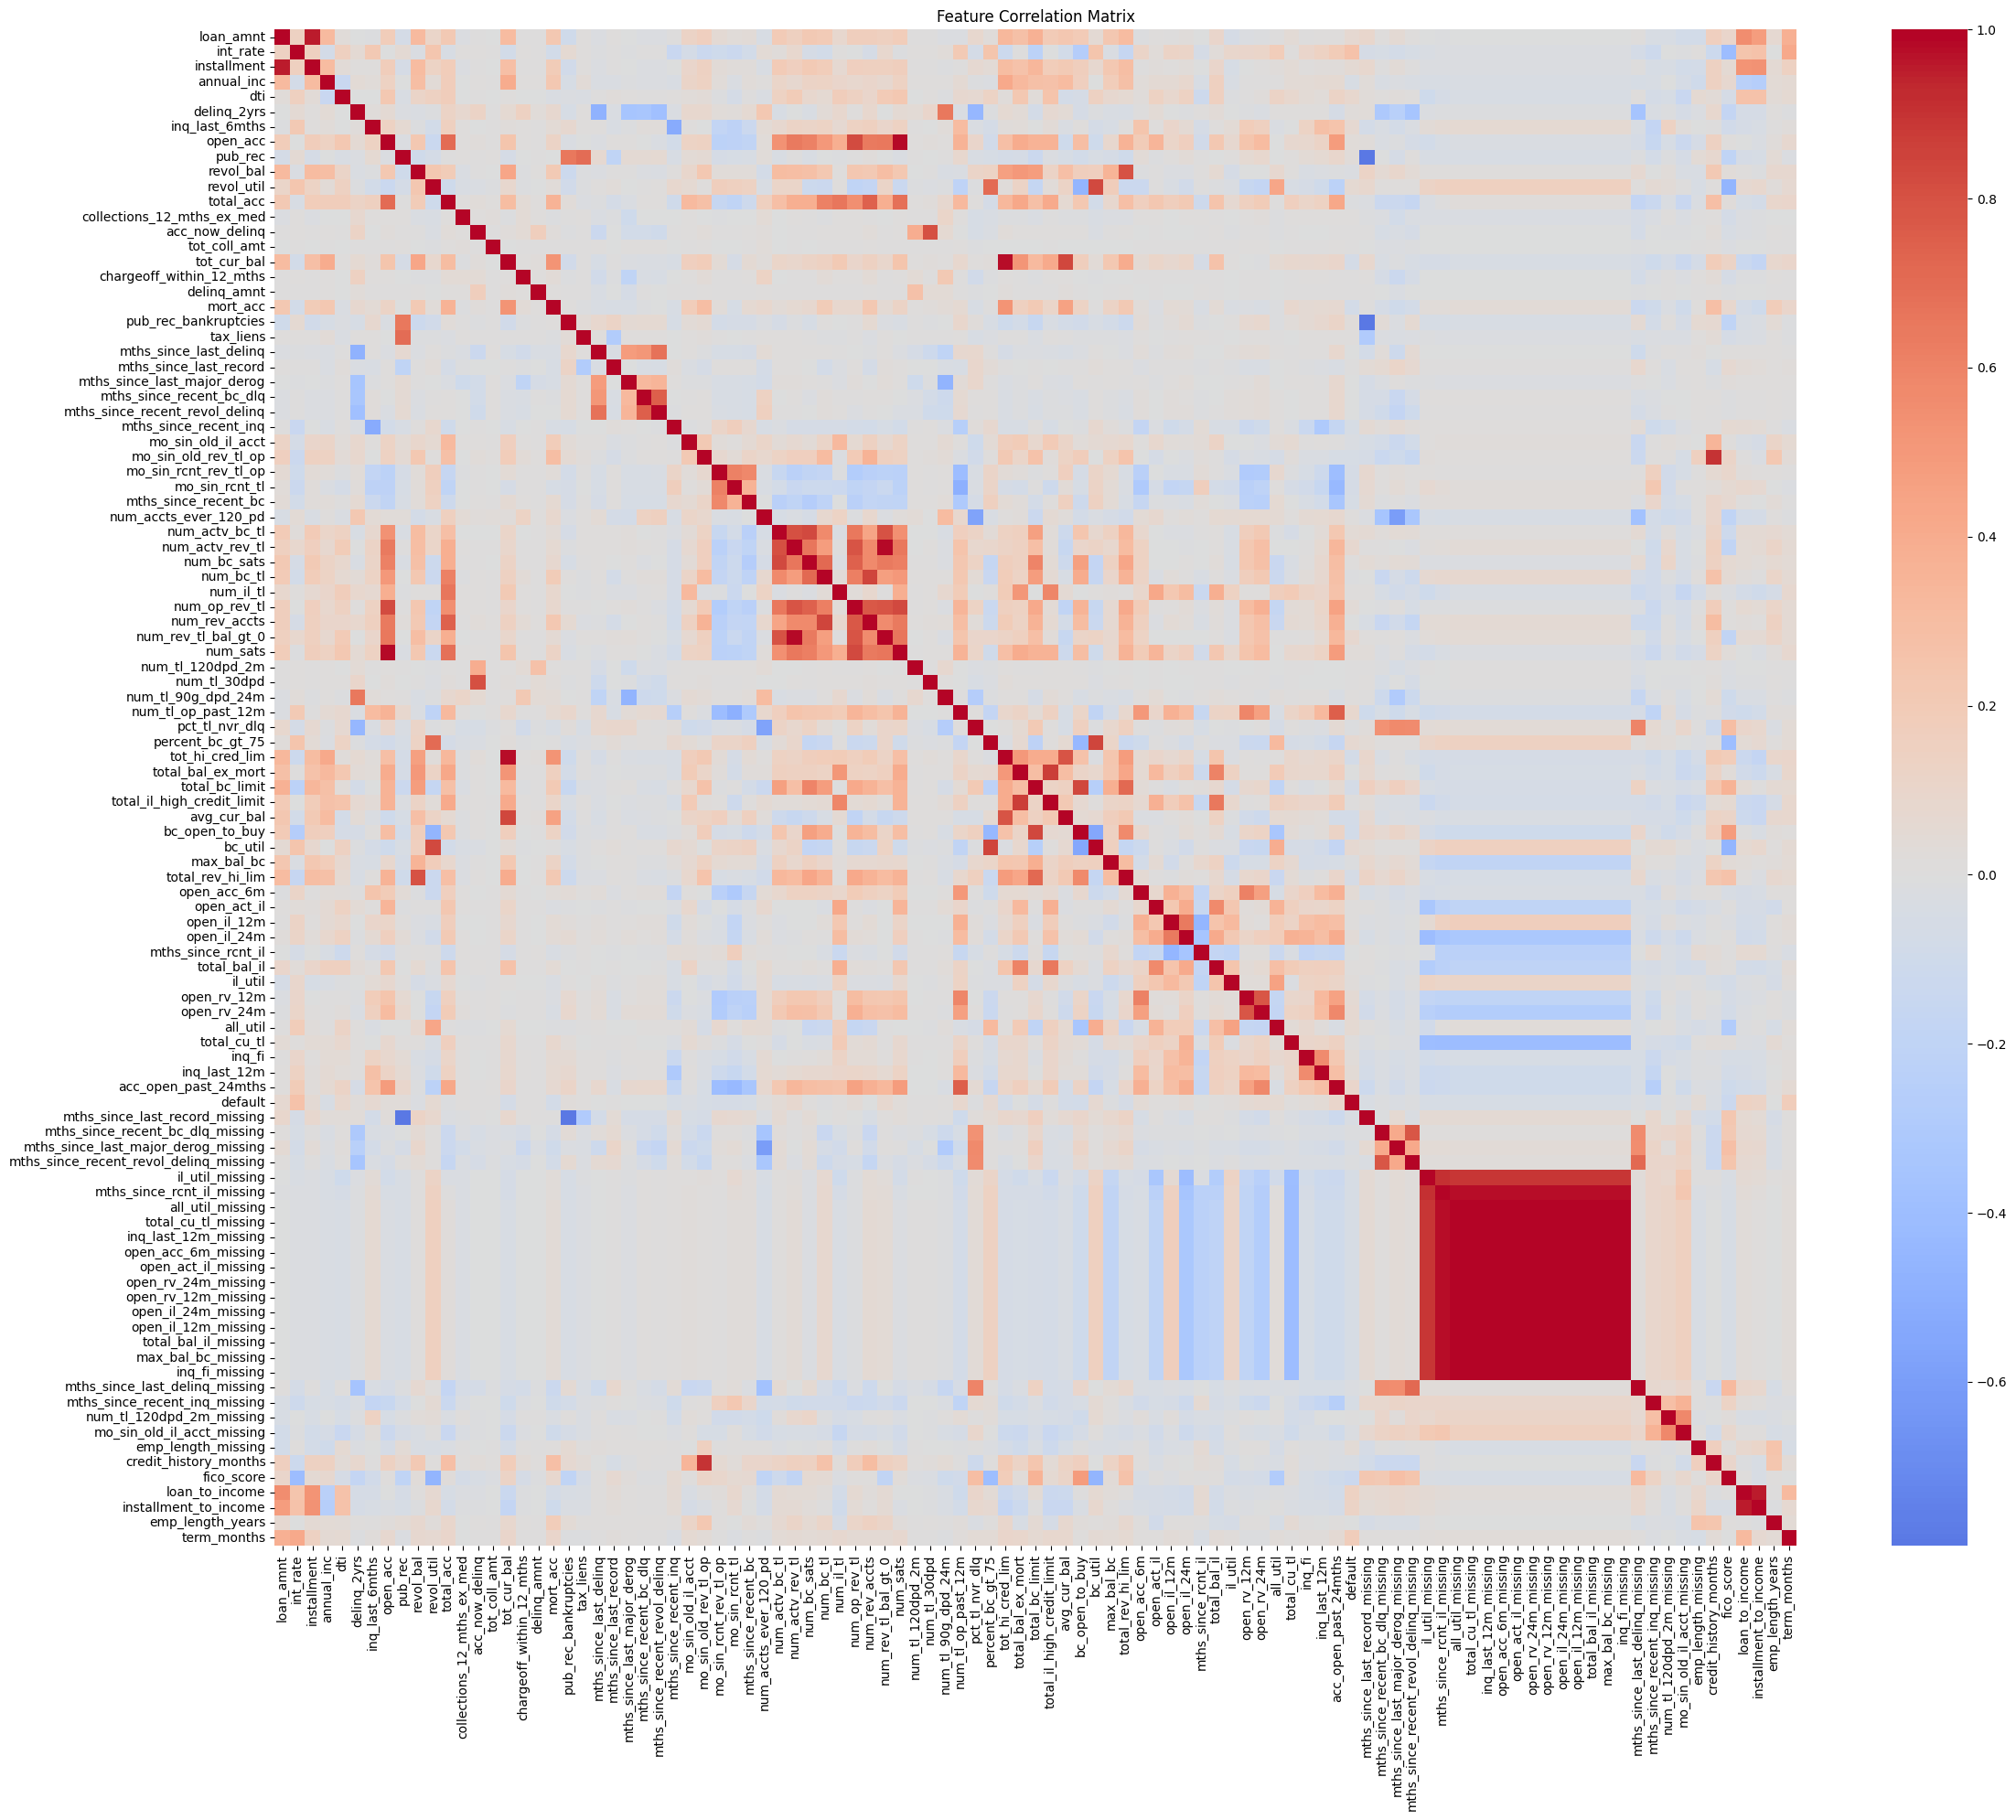

Saved locally: C:\Users\Nafis\BuildersLab_projects\Projects_Cleanup\Credit-Risk-Default\outputs\feature_correlation_matrix.png


In [13]:
# Display and save the correlation matrix heatmap
import seaborn as sns

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()

heatmap_path = os.path.join(OUTPUT_DIR, "feature_correlation_matrix.png")
plt.savefig(heatmap_path, dpi=150)
plt.show()
print(f"Saved locally: {heatmap_path}")

<h3 style="color:orange"><a id="5-confirmed-features"></a>5. Confirmed Features</h3>

All new created features were checked for correlation with `default` (see Feature Validation above): `term_months` (0.176), `loan_to_income` (0.135), `fico_score` (-0.131), `installment_to_income` (0.118), `credit_history_months` (-0.034), `emp_length_years` (-0.002). None show the near-1.0 correlation that would signal leakage.

| Feature |
|---|
| `credit_history_months` |
| `fico_score` |
| `loan_to_income` |
| `installment_to_income` |
| `emp_length_years` |
| `term_months` |

<h2 style="color:orange"><a id="missingness-check"></a>IV. Missingness Check</h2>

Confirm feature engineering didn't introduce any nulls or missing values.

In [14]:
print("Missingness check after feature engineering:\n")
for name, split in SPLITS.items():
    nulls = split.isnull().sum()
    nulls = nulls[nulls > 0]
    total = int(split.isnull().sum().sum())
    print(f"{name}: {len(nulls)} columns with missing values, {total} total nulls")
    if len(nulls):
        print(nulls)
    print()

Missingness check after feature engineering:



train: 0 columns with missing values, 0 total nulls

val: 0 columns with missing values, 0 total nulls



test: 0 columns with missing values, 0 total nulls



<h2 style="color:orange"><a id="data-dictionary-export"></a>V. Data Dictionary & Statistics Export</h2>

Build a 4-sheet Excel workbook documenting the final feature-engineered dataset, saved locally here; uploaded to Hugging Face together with everything else in the final Save section below.

1. **Data Dictionary**: every column's description and dtype (numeric/categorical).
2. **Dictionary + Statistics**: the same, plus per-column stats, min/max/mean/std/percentiles for numeric columns, unique/top/freq for categorical columns, and missing value count/percentage for all.
3. **Correlation Matrix**: feature x feature correlation (reused from the Correlation Matrix section above).
4. **Correlation vs Target**: feature x `default` correlation (reused from the Correlation Matrix section above).

In [15]:
# Sheet 1: Data Dictionary
raw_dictionary = pd.read_csv(os.path.join(OUTPUT_DIR, "data_dictionary_summary.csv"))
description_map = dict(zip(raw_dictionary["Variable"], raw_dictionary["Description"]))

# Descriptions for columns that don't exist in the raw Kaggle dictionary: the target and the six features engineered in this notebook.
CUSTOM_DESCRIPTIONS = {
    "default": "Binary target: 1 if the loan defaulted (Charged Off or Default), 0 if fully repaid.",
    "credit_history_months": "Months between the borrower's earliest reported credit line and this loan's issue date.",
    "fico_score": "Midpoint of the borrower's reported FICO range at origination: (fico_range_low + fico_range_high) / 2.",
    "loan_to_income": "loan_amnt / annual_inc, winsorized at the 99.9th percentile (see Domain-Specific Features above).",
    "installment_to_income": "(installment * 12) / annual_inc, winsorized at the 99.9th percentile (see Domain-Specific Features above).",
    "emp_length_years": "Employment length converted from text (e.g. \"10+ years\") to a plain ordinal number (0-10).",
    "term_months": "Loan term converted from text (e.g. \"36 months\") to plain numeric months (36 or 60).",
}

# Define a function to describe columns based on the custom descriptions and the raw dictionary
def describe_column(col):
    if col in CUSTOM_DESCRIPTIONS:
        return CUSTOM_DESCRIPTIONS[col]
    if col in description_map:
        return description_map[col]
    if col.endswith("_missing"):
        base = col[: -len("_missing")]
        base_desc = description_map.get(base, base)
        return f"Missing-value indicator flag: 1 if `{base}` was missing before imputation, 0 otherwise. ({base_desc})"
    return "No description available."

# Create a data dictionary DataFrame with variable names, descriptions, and data types
dictionary_df = pd.DataFrame(
    {
        "Variable": train.columns,
        "Description": [describe_column(c) for c in train.columns],
        "Dtype": [
            "Numeric" if pd.api.types.is_numeric_dtype(train[c]) else "Categorical"
            for c in train.columns
        ],
    }
)

# Display the data dictionary DataFrame
dictionary_df

Variable  \
0                                 loan_amnt   
1                                  int_rate   
2                               installment   
3                            home_ownership   
4                                annual_inc   
5                       verification_status   
6                                   purpose   
7                          application_type   
8                                addr_state   
9                                       dti   
10                              delinq_2yrs   
11                           inq_last_6mths   
12                                 open_acc   
13                                  pub_rec   
14                                revol_bal   
15                               revol_util   
16                                total_acc   
17               collections_12_mths_ex_med   
18                           acc_now_delinq   
19                             tot_coll_amt   
20                              tot_cur_bal   
21                 chargeoff_within_12_mths   
22                              delinq_amnt   
23                                 mort_acc   
24                     pub_rec_bankruptcies   
25                                tax_liens   
26                   mths_since_last_delinq   
27                   mths_since_last_record   
28              mths_since_last_major_derog   
29                 mths_since_recent_bc_dlq   
30           mths_since_recent_revol_delinq   
31                    mths_since_recent_inq   
32                       mo_sin_old_il_acct   
33                     mo_sin_old_rev_tl_op   
34                    mo_sin_rcnt_rev_tl_op   
35                           mo_sin_rcnt_tl   
36                     mths_since_recent_bc   
37                    num_accts_ever_120_pd   
38                           num_actv_bc_tl   
39                          num_actv_rev_tl   
40                              num_bc_sats   
41                                num_bc_tl   
42                                num_il_tl   
43                            num_op_rev_tl   
44                            num_rev_accts   
45                      num_rev_tl_bal_gt_0   
46                                 num_sats   
47                         num_tl_120dpd_2m   
48                             num_tl_30dpd   
49                       num_tl_90g_dpd_24m   
50                       num_tl_op_past_12m   
51                           pct_tl_nvr_dlq   
52                         percent_bc_gt_75   
53                          tot_hi_cred_lim   
54                        total_bal_ex_mort   
55                           total_bc_limit   
56               total_il_high_credit_limit   
57                              avg_cur_bal   
58                           bc_open_to_buy   
59                                  bc_util   
60                               max_bal_bc   
61                         total_rev_hi_lim   
62                              open_acc_6m   
63                              open_act_il   
64                              open_il_12m   
65                              open_il_24m   
66                       mths_since_rcnt_il   
67                             total_bal_il   
68                                  il_util   
69                              open_rv_12m   
70                              open_rv_24m   
71                                 all_util   
72                              total_cu_tl   
73                                   inq_fi   
74                             inq_last_12m   
75                     acc_open_past_24mths   
76                      initial_list_status   
77                      disbursement_method   
78                                  default   
79           mths_since_last_record_missing   
80         mths_since_recent_bc_dlq_missing   
81      mths_since_last_major_derog_missing   
82   mths_since_recent_revol_delinq_missing   
83                          il_util_missing   
84               mths_since_rcnt_il_miss

In [16]:
# Sheet 2: Dictionary + Statistics (numeric and categorical, plus missing values)

# Identify numeric and categorical columns
numeric_cols = train.select_dtypes(include=np.number).columns
categorical_cols = train.select_dtypes(exclude=np.number).columns

# Compute descriptive statistics for numeric and categorical columns
numeric_stats = train[numeric_cols].describe().T.rename(
    columns={"25%": "p25", "50%": "median", "75%": "p75"}
)
categorical_stats = train[categorical_cols].describe().T  # count, unique, top, freq

# Compute missing value counts and percentages
missing_counts = train.isnull().sum()
missing_pct = (train.isnull().mean() * 100).round(3)

# Create a combined statistics DataFrame with variable names, descriptions, data types, and statistics
stats_rows = []
for col in train.columns:
    row = {
        "Variable": col,
        "Description": describe_column(col),
        "Dtype": "Numeric" if col in numeric_cols else "Categorical",
        "missing_count": int(missing_counts[col]),
        "missing_pct": missing_pct[col],
    }
    if col in numeric_cols:
        s = numeric_stats.loc[col]
        row.update(
            {
                "count": s["count"], "mean": s["mean"], "std": s["std"], "min": s["min"],
                "p25": s["p25"], "median": s["median"], "p75": s["p75"], "max": s["max"],
                "unique": None, "top": None, "freq": None,
            }
        )
    else:
        s = categorical_stats.loc[col]
        row.update(
            {
                "count": s["count"], "mean": None, "std": None, "min": None,
                "p25": None, "median": None, "p75": None, "max": None,
                "unique": s["unique"], "top": s["top"], "freq": s["freq"],
            }
        )
    stats_rows.append(row)
    
# Create a DataFrame from the stats rows
dictionary_stats_df = pd.DataFrame(stats_rows)
dictionary_stats_df

Variable  \
0                                 loan_amnt   
1                                  int_rate   
2                               installment   
3                            home_ownership   
4                                annual_inc   
5                       verification_status   
6                                   purpose   
7                          application_type   
8                                addr_state   
9                                       dti   
10                              delinq_2yrs   
11                           inq_last_6mths   
12                                 open_acc   
13                                  pub_rec   
14                                revol_bal   
15                               revol_util   
16                                total_acc   
17               collections_12_mths_ex_med   
18                           acc_now_delinq   
19                             tot_coll_amt   
20                              tot_cur_bal   
21                 chargeoff_within_12_mths   
22                              delinq_amnt   
23                                 mort_acc   
24                     pub_rec_bankruptcies   
25                                tax_liens   
26                   mths_since_last_delinq   
27                   mths_since_last_record   
28              mths_since_last_major_derog   
29                 mths_since_recent_bc_dlq   
30           mths_since_recent_revol_delinq   
31                    mths_since_recent_inq   
32                       mo_sin_old_il_acct   
33                     mo_sin_old_rev_tl_op   
34                    mo_sin_rcnt_rev_tl_op   
35                           mo_sin_rcnt_tl   
36                     mths_since_recent_bc   
37                    num_accts_ever_120_pd   
38                           num_actv_bc_tl   
39                          num_actv_rev_tl   
40                              num_bc_sats   
41                                num_bc_tl   
42                                num_il_tl   
43                            num_op_rev_tl   
44                            num_rev_accts   
45                      num_rev_tl_bal_gt_0   
46                                 num_sats   
47                         num_tl_120dpd_2m   
48                             num_tl_30dpd   
49                       num_tl_90g_dpd_24m   
50                       num_tl_op_past_12m   
51                           pct_tl_nvr_dlq   
52                         percent_bc_gt_75   
53                          tot_hi_cred_lim   
54                        total_bal_ex_mort   
55                           total_bc_limit   
56               total_il_high_credit_limit   
57                              avg_cur_bal   
58                           bc_open_to_buy   
59                                  bc_util   
60                               max_bal_bc   
61                         total_rev_hi_lim   
62                              open_acc_6m   
63                              open_act_il   
64                              open_il_12m   
65                              open_il_24m   
66                       mths_since_rcnt_il   
67                             total_bal_il   
68                                  il_util   
69                              open_rv_12m   
70                              open_rv_24m   
71                                 all_util   
72                              total_cu_tl   
73                                   inq_fi   
74                             inq_last_12m   
75                     acc_open_past_24mths   
76                      initial_list_status   
77                      disbursement_method   
78                                  default   
79           mths_since_last_record_missing   
80         mths_since_recent_bc_dlq_missing   
81      mths_since_last_major_derog_missing   
82   mths_since_recent_revol_delinq_missing   
83                          il_util_missing   
84               mths_since_rcnt_il_miss

In [17]:
# Write the 4-sheet workbook locally
EXCEL_FILENAME = "feature_engineering_data_dictionary.xlsx"
excel_path = os.path.join(OUTPUT_DIR, EXCEL_FILENAME)

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    dictionary_df.to_excel(writer, sheet_name="Data Dictionary", index=False)
    dictionary_stats_df.to_excel(writer, sheet_name="Dictionary + Statistics", index=False)
    corr_matrix.to_excel(writer, sheet_name="Correlation Matrix")
    target_corr_df.to_excel(writer, sheet_name="Correlation vs Target", index=False)

print(f"Saved locally: {excel_path}")

Saved locally: C:\Users\Nafis\BuildersLab_projects\Projects_Cleanup\Credit-Risk-Default\outputs\feature_engineering_data_dictionary.xlsx


<h2 style="color:orange"><a id="save-to-huggingface"></a>VI. Save the Dataset</h2>

Save everything this notebook produced, locally and to Hugging Face, in one place: the feature-engineered train/val/test splits, the correlation matrix CSV and heatmap PNG (uploaded to a general `outputs/` folder, shared with future artifacts like SHAP plots and evaluation curves), and the data dictionary Excel workbook.

In [18]:
import os
from pathlib import Path

from dotenv import load_dotenv
from huggingface_hub import HfApi, hf_hub_download

load_dotenv(os.path.join(BASE_DIR, ".env"))

REPO_ID = "BuildersLab/loan-application-dataset"
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")

SPLIT_FILES = {
    "train": ("train_after_feature_engineering.parquet", train),
    "val": ("val_after_feature_engineering.parquet", val),
    "test": ("test_after_feature_engineering.parquet", test),
}

# Save the splits locally
for name, (filename, split) in SPLIT_FILES.items():
    path = os.path.join(PROCESSED_DIR, filename)
    split.to_parquet(path, index=False)
    print(f"{name}: saved {filename} ({split.shape[0]:,} rows, {split.shape[1]} cols)")

token = os.getenv("HF_TOKEN")
if not token:
    raise RuntimeError(
        "Set HF_TOKEN in .env (https://huggingface.co/settings/tokens, "
        "needs write access to the BuildersLab org)."
    )
api = HfApi(token=token)

# Every file this notebook produced, local path -> path in the HF repo
UPLOADS = {
    os.path.join(PROCESSED_DIR, "train_after_feature_engineering.parquet"): "data/after_feature_engineering/train.parquet",
    os.path.join(PROCESSED_DIR, "val_after_feature_engineering.parquet"): "data/after_feature_engineering/val.parquet",
    os.path.join(PROCESSED_DIR, "test_after_feature_engineering.parquet"): "data/after_feature_engineering/test.parquet",
    matrix_path: "outputs/feature_correlation_matrix.csv",
    heatmap_path: "outputs/feature_correlation_matrix.png",
    excel_path: f"data_dictionary/{EXCEL_FILENAME}",
}

print()
for local_path, path_in_repo in UPLOADS.items():
    print(f"Uploading {os.path.basename(local_path)} -> {path_in_repo} ...")
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo=path_in_repo,
        repo_id=REPO_ID,
        repo_type="dataset",
        commit_message=f"Update {path_in_repo}",
    )

print(f"\nDone: https://huggingface.co/datasets/{REPO_ID}/tree/main")

# Register a "feature_engineered" config so load_dataset(REPO_ID, "feature_engineered")
# picks up these splits without touching the existing default config.
readme_path = hf_hub_download(
    repo_id=REPO_ID, filename="README.md", repo_type="dataset", token=token
)
readme = Path(readme_path).read_text(encoding="utf-8")
_, yaml_block, body = readme.split("---\n", 2)

feature_engineered_config = (
    "- config_name: feature_engineered\n"
    "  data_files:\n"
    "  - split: train\n"
    "    path: data/after_feature_engineering/train.parquet\n"
    "  - split: validation\n"
    "    path: data/after_feature_engineering/val.parquet\n"
    "  - split: test\n"
    "    path: data/after_feature_engineering/test.parquet\n"
)

if "config_name: feature_engineered" in yaml_block:
    print("feature_engineered config already present, skipping README update.")
else:
    default_marker = "- config_name: default\n"
    insert_after = yaml_block.index(default_marker) + len(default_marker)
    next_config_at = yaml_block.index("- config_name:", insert_after)
    yaml_block = (
        yaml_block[:next_config_at] + feature_engineered_config + yaml_block[next_config_at:]
    )
    updated = "---\n" + yaml_block + "---\n" + body
    Path(readme_path).write_text(updated, encoding="utf-8")
    api.upload_file(
        path_or_fileobj=readme_path,
        path_in_repo="README.md",
        repo_id=REPO_ID,
        repo_type="dataset",
        commit_message="Add feature_engineered config for the post-feature-engineering dataset",
    )
    print("README.md updated with feature_engineered config.")

train: saved train_after_feature_engineering.parquet (941,744 rows, 108 cols)


val: saved val_after_feature_engineering.parquet (201,803 rows, 108 cols)


test: saved test_after_feature_engineering.parquet (201,802 rows, 108 cols)

Uploading train_after_feature_engineering.parquet -> data/after_feature_engineering/train.parquet ...


Uploading val_after_feature_engineering.parquet -> data/after_feature_engineering/val.parquet ...


Uploading test_after_feature_engineering.parquet -> data/after_feature_engineering/test.parquet ...


...

Uploading feature_engineering_data_dictionary.xlsx -> data_dictionary/feature_engineering_data_dictionary.xlsx ...


feature_engineering_data_dictionary.xlsx:   0%|          | 0.00/141k [00:00<?, ?B/s]


Done: https://huggingface.co/datasets/BuildersLab/loan-application-dataset/tree/main


README.md: 0.00B [00:00, ?B/s]

feature_engineered config already present, skipping README update.
